VIP顧客_売り上げの全体に対する割合 28.113604208584647 %
VIP顧客_数の全体に対する割合 23.101555352241537 %


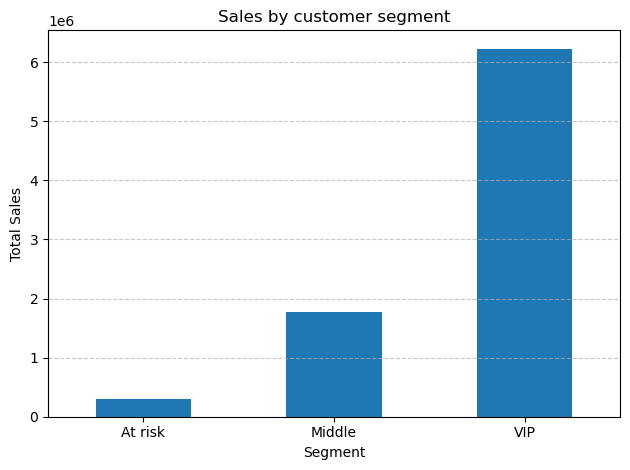

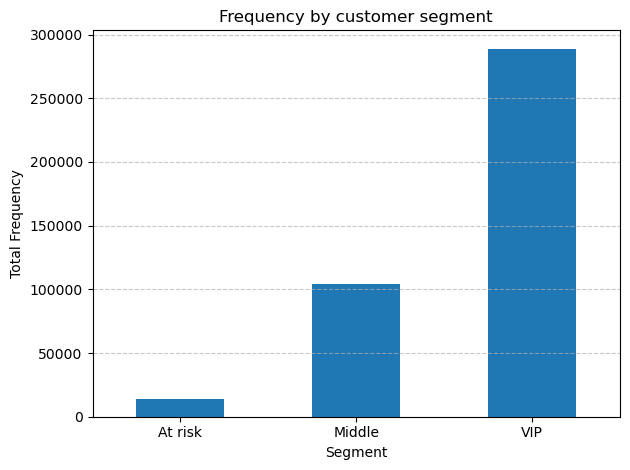

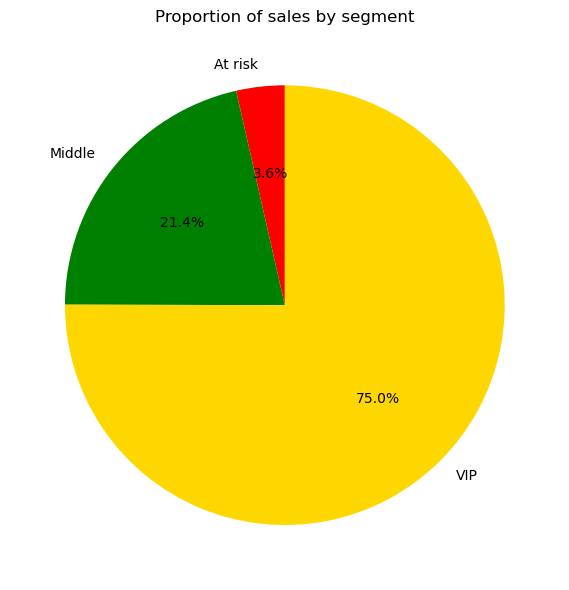

In [1]:
# ============================
# 1.データ読み込み
# ============================
import pandas as pd

online_retail = pd.read_excel("../data/Online Retail.xlsx")

# ============================
# 2.Data cleaning
# ============================
online_retail_1 = online_retail.dropna(subset='CustomerID')

# ============================
# 3.Feature engineering
# ============================
online_retail_1 = online_retail_1.copy()
online_retail_1["Total Price"] = online_retail_1["Quantity"] * online_retail_1["UnitPrice"]

# ============================
# 4.RFM aggregation
# ============================
# rfm_ = online_retail_1.groupby("CustomerID")["Total Price"].sum()
rfm  = online_retail_1.groupby("CustomerID").agg({
    'InvoiceDate':'max', # 最後に買った日
    'InvoiceNo':'count',
    'Total Price':'sum'
})
rfm.columns = ["LastPurchaseDate","Frequency","Monetary"]

# ============================
# 5.Recency calclation
# ============================
now = online_retail_1["InvoiceDate"].max()
rfm["Recency"] = (now - rfm["LastPurchaseDate"]).dt.days

# ============================
# 6.Rank Scoring 
# ============================
rfm["R_score"] = pd.qcut(rfm["Recency"]  ,4 , labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"],4 , labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"] ,4 , labels=[1,2,3,4])

# ============================
# 7. Extract VIP data
# ============================
vip_customers = rfm[ 
    (rfm["R_score"] >= 3) &
    (rfm["F_score"] >= 3) &
    (rfm["M_score"] >= 3) 
]

# ============================
# 8. VIP ratio calclation
# ============================
vip_sales_total = vip_customers["Monetary"].sum()
total_sales     = rfm["Monetary"].sum()
vip_ratio       = vip_sales_total / total_sales

# ============================
# 9. Result
# ============================
print("VIP顧客_売り上げの全体に対する割合",vip_ratio * 100,"%")

print("VIP顧客_数の全体に対する割合",(len(vip_customers)/len(rfm)) * 100, "%")

# ============================
# 10. Customer Segmentation
# ============================
def customer_rank(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "VIP"
    elif row["R_score"] == 1 and row["Frequency"] <= rfm["Frequency"].median():
        return "At risk"
    else:
        return "Middle"

rfm["customer_rank"] = rfm.apply(customer_rank,axis = 1)

# ============================
# 11. Sales bar graph drawing 
# ============================
import matplotlib.pyplot as plt
segment_sales = rfm.groupby("customer_rank")["Monetary"].sum()
plt.figure()
segment_sales.plot(kind = "bar")
plt.title("Sales by customer segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================
# 12. Frequency bar graph drawing 
# ============================
segment_counts = rfm.groupby("customer_rank")["Frequency"].sum()

plt.figure()
segment_counts.plot(kind = "bar")
plt.title("Frequency by customer segment")
plt.xlabel("Segment")
plt.ylabel("Total Frequency")
plt.xticks(rotation=0)
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()

# ============================
# 13. Pie chart of Sales by segment
# ============================
colors = {
    "VIP": "gold",
    "Middle": "green",
    "At risk": "red"
}

plt.figure(figsize=(6,6))
segment_sales.plot(kind="pie",autopct="%1.1f%%",startangle=90,
                  colors = [colors[i] for i in segment_sales.index])
plt.title("Proportion of sales by segment")
plt.ylabel("")
plt.tight_layout()
plt.show()